In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [3]:
df = pd.read_csv('titanic_data.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


#### Understanding data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
df.shape

(418, 12)

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


### Check missing values

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

### Handle missing values

In [9]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,27.0,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,27.0,0,0,359309,8.0500,NaN,S


In [10]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,27.0,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,27.0,0,0,359309,8.0500,NaN,S


In [11]:
## Cabin - Drop column
df.drop('Cabin', axis=1, inplace=True)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,27.0,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",male,27.0,0,0,359309,8.0500,S


In [12]:
## Fare - Fill with Median
df['Fare'].fillna(df['Fare'].median(), inplace=True)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,27.0,0,0,A.5. 3236,8.0500,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,0,3,"Ware, Mr. Frederick",male,27.0,0,0,359309,8.0500,S


In [13]:
## Verify again
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## UNIVARIATE ANALYSIS

#### Survival

In [14]:
## Survival percentage
survival_rate = df['Survived'].mean()*100
print("Survival Rate:", survival_rate)

Survival Rate: 36.36363636363637


In [15]:
# Count of 0 and 1
survival_counts = df['Survived'].value_counts()

print(survival_counts)

Survived
0    266
1    152
Name: count, dtype: int64


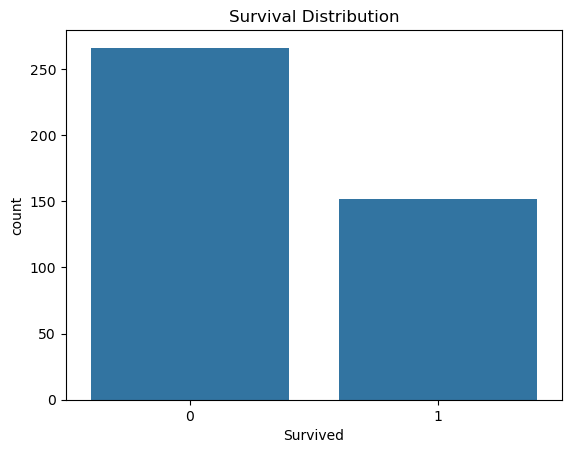

In [16]:
# Count plot
sns.countplot(x='Survived', data=df)
plt.title("Survival Distribution")
plt.show()

#### Age

In [17]:
# What is the average, median, and mode age?
print("Mean:", df['Age'].mean())
print("Median:", df['Age'].median())
print("Mode:", df['Age'].mode()[0])

Mean: 29.599282296650717
Median: 27.0
Mode: 27.0


In [18]:
# What is the age range (min–max)?
print("Min:", df['Age'].min())
print("Max:", df['Age'].max())

Min: 0.17
Max: 76.0


In [19]:
# Are there missing values in Age?
print("Missing:", df['Age'].isnull().sum())

Missing: 0


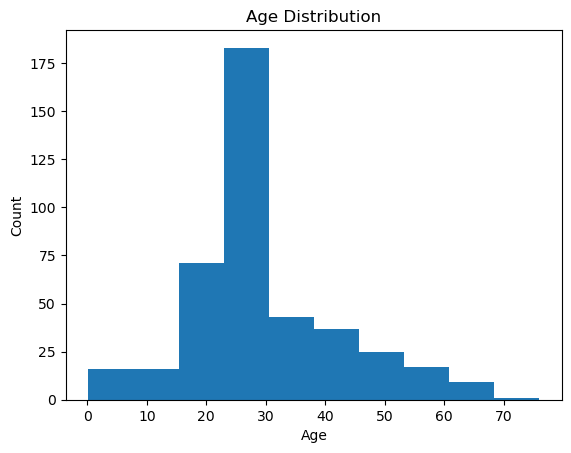

In [20]:
# Histogram
plt.hist(df['Age'].dropna())
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

#### Gender

In [21]:
print(df['Sex'].value_counts())

Sex
male      266
female    152
Name: count, dtype: int64


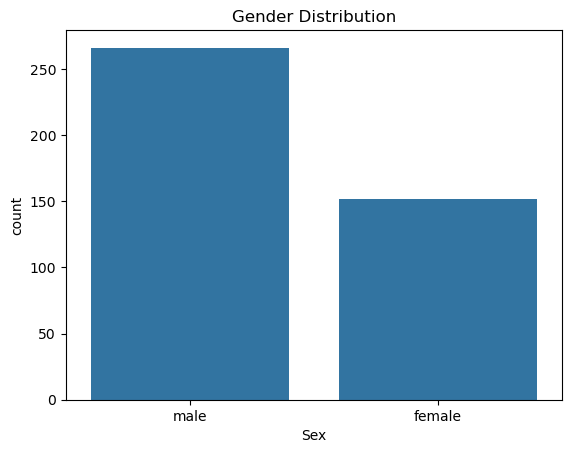

In [22]:
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")
plt.show()

In [23]:
print("Missing:", df['Sex'].isnull().sum())

Missing: 0


#### Passenger class

In [24]:
## How many passengers were in each class (1st, 2nd, 3rd)?
print(df['Pclass'].value_counts())

Pclass
3    218
1    107
2     93
Name: count, dtype: int64


In [25]:
# Class with highest passengers
most_common_class = df['Pclass'].value_counts().idxmax()

print("Class with most passengers:", most_common_class)

Class with most passengers: 3


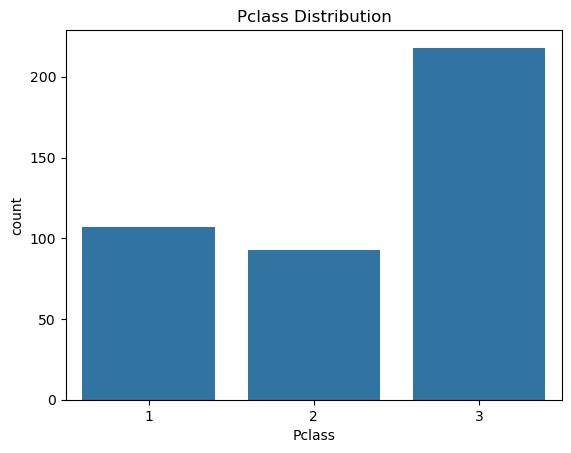

In [26]:
# What is the distribution of Pclass?
sns.countplot(x='Pclass', data=df)
plt.title("Pclass Distribution")
plt.show()

#### Fare

In [27]:
# What is the average and median fare?
print("Mean:", df['Fare'].mean())
print("Median:", df['Fare'].median())

Mean: 35.57653540669856
Median: 14.4542


In [28]:
# What is the fare range?
print("Min:", df['Fare'].min())
print("Max:", df['Fare'].max())

Min: 0.0
Max: 512.3292


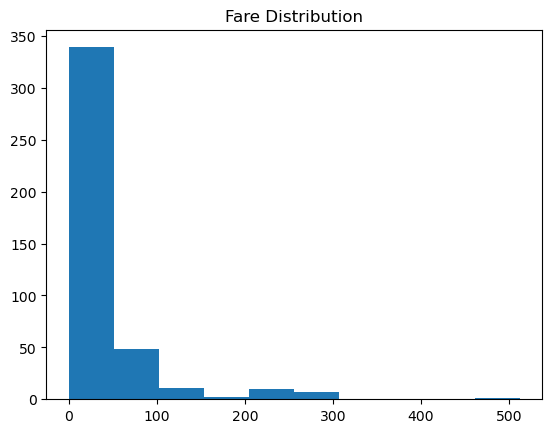

In [29]:
# Histogram
plt.hist(df['Fare'])
plt.title("Fare Distribution")
plt.show()

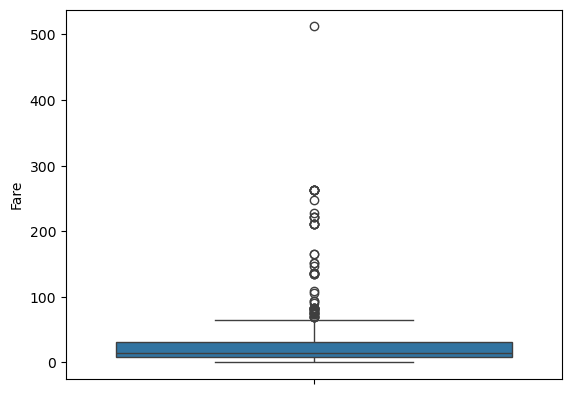

In [30]:
# Boxplot (Outliers)
sns.boxplot(y='Fare', data=df)
plt.show()

### Family Features
#### SibSp(Siblings/Spouses abroad)

In [31]:
# What is the most common number of siblings/spouses?
print(df['SibSp'].value_counts())

SibSp
0    283
1    110
2     14
3      4
4      4
8      2
5      1
Name: count, dtype: int64


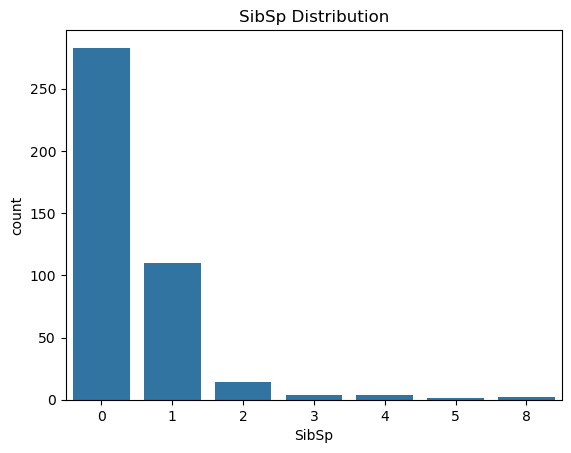

In [32]:
# What is the distribution of SibSp?
sns.countplot(x='SibSp', data=df)
plt.title("SibSp Distribution")
plt.show()

#### Parch(Parents/children abroad)

In [33]:
# What is the most common number of parents/children?
print(df['Parch'].value_counts())

Parch
0    324
1     52
2     33
3      3
4      2
9      2
6      1
5      1
Name: count, dtype: int64


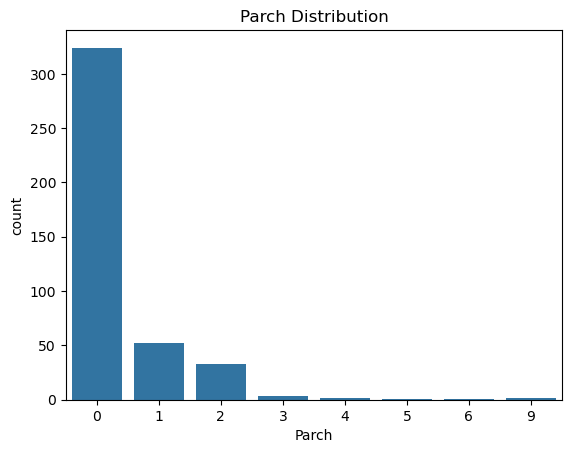

In [34]:
# What is the distribution of Parch?
sns.countplot(x='Parch', data=df)
plt.title("Parch Distribution")
plt.show()

#### Embarked

In [35]:
# How many passengers embarked from each port?
print(df['Embarked'].value_counts())

Embarked
S    270
C    102
Q     46
Name: count, dtype: int64


In [36]:
# Which port is most common?
most_common_port = df['Embarked'].value_counts().idxmax()

print("Most common port:", most_common_port)

Most common port: S


In [37]:
# Are there missing values in Embarked?
print("Missing:", df['Embarked'].isnull().sum())

Missing: 0


#### Ticket

In [38]:
# How many unique tickets are there?
print("Unique Tickets:", df['Ticket'].nunique())

Unique Tickets: 363


In [39]:
# What is the most frequent ticket number?
print("Most Frequent Ticket:", df['Ticket'].value_counts().idxmax())

Most Frequent Ticket: PC 17608


### BIVARIATE ANALYSIS (SUBPLOTS)

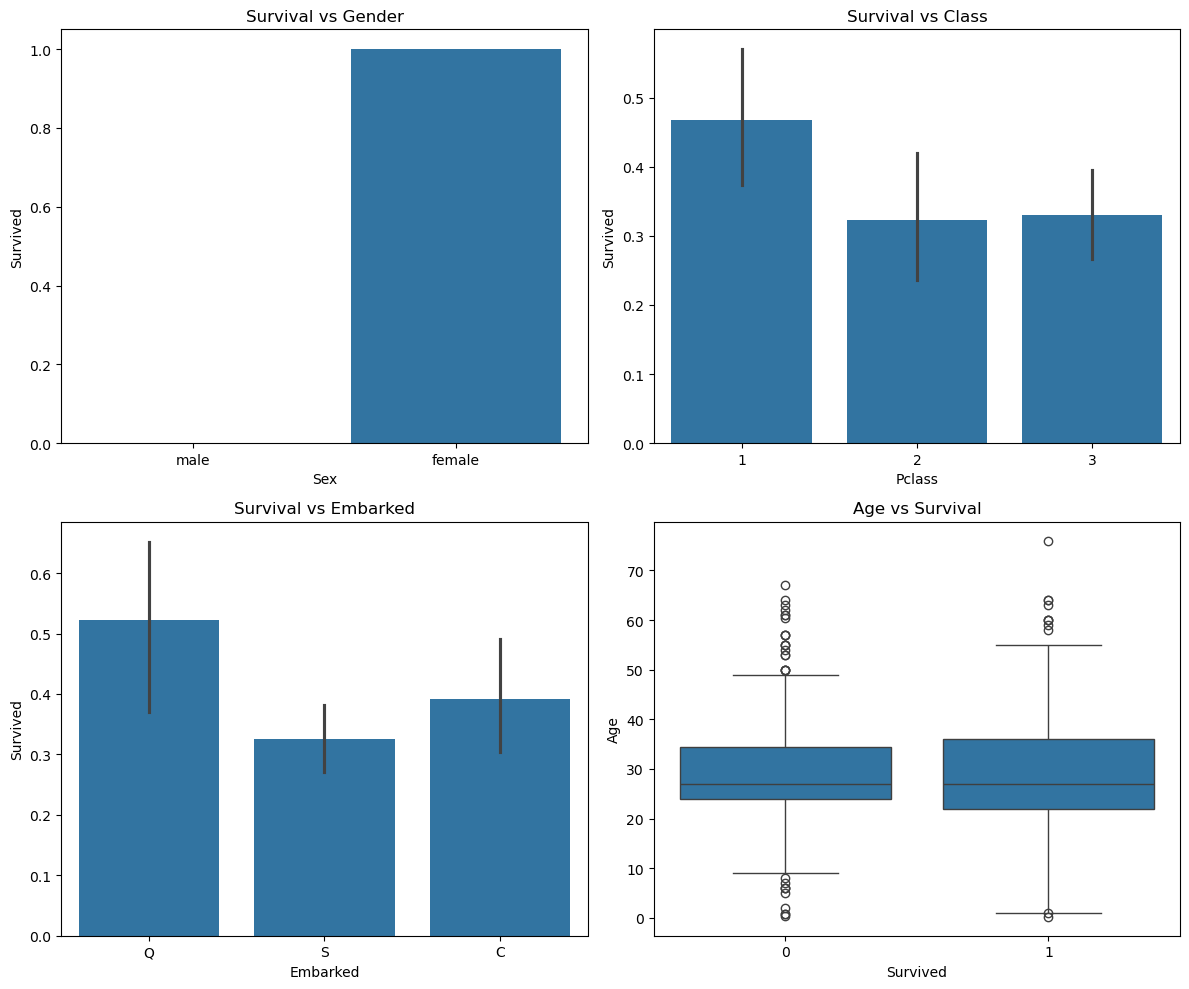

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0,0])
axes[0,0].set_title("Survival vs Gender")

sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[0,1])
axes[0,1].set_title("Survival vs Class")

sns.barplot(x='Embarked', y='Survived', data=df, ax=axes[1,0])
axes[1,0].set_title("Survival vs Embarked")

sns.boxplot(x='Survived', y='Age', data=df, ax=axes[1,1])
axes[1,1].set_title("Age vs Survival")

plt.tight_layout()
plt.show()

### Pairplot

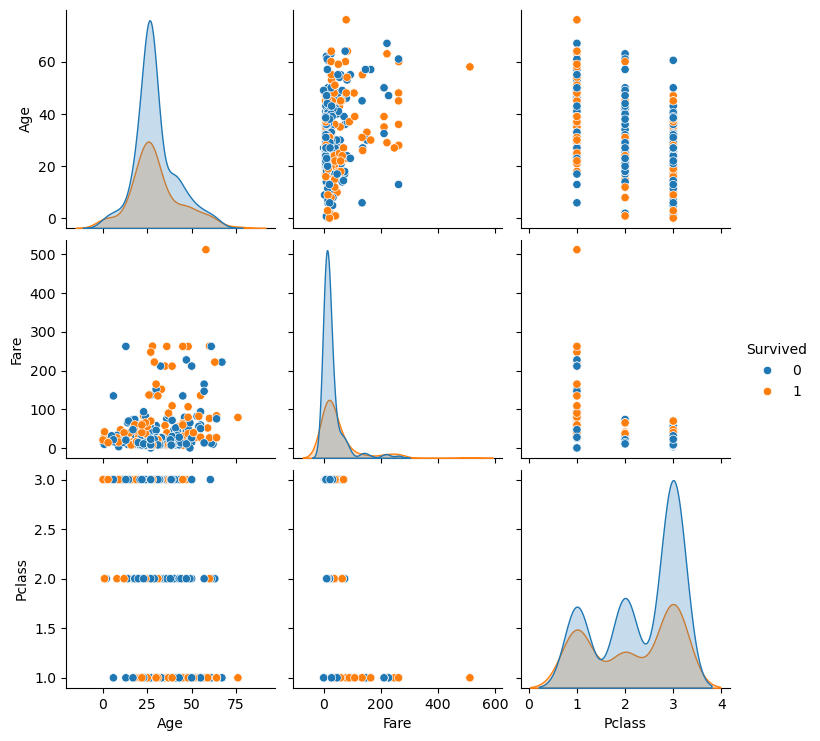

In [41]:
sns.pairplot(df[['Survived','Age','Fare','Pclass']], hue='Survived')
plt.show()

### Boxplot

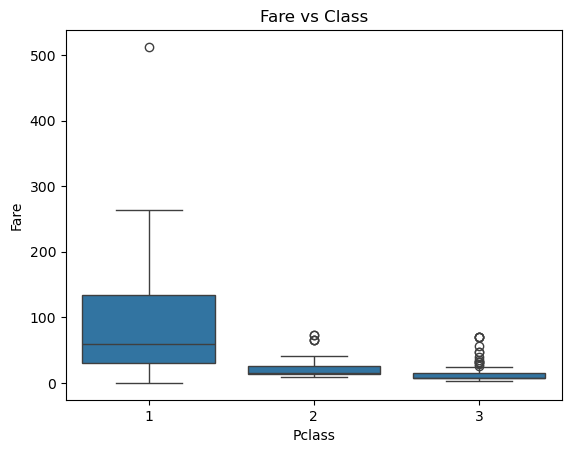

In [42]:
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title("Fare vs Class")
plt.show()

### Area chart

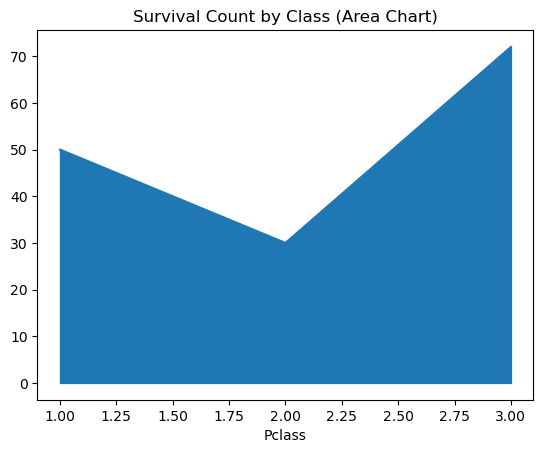

In [43]:
df.groupby('Pclass')['Survived'].sum().plot(kind='area')
plt.title("Survival Count by Class (Area Chart)")
plt.show()

### Selective Correlation Heatmap

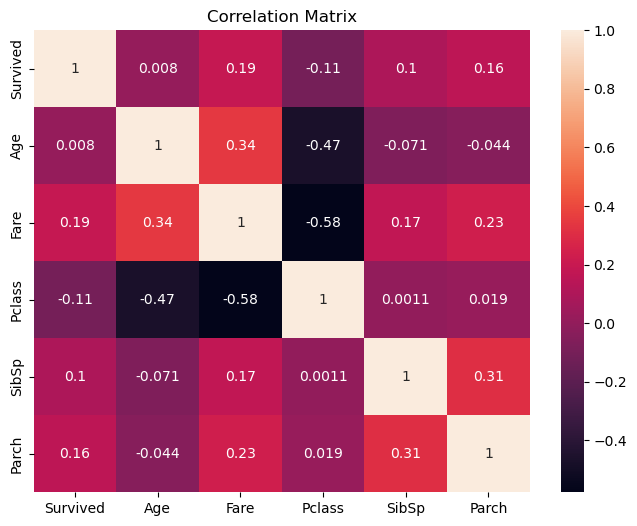

In [44]:
corr = df[['Survived','Age','Fare','Pclass','SibSp','Parch']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()